In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import ast 
from datasets import load_dataset 

c:\Users\agarw\Desktop\Python Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#loading Data 
dataset = load_dataset('lukebarousse/data_jobs') 
df = dataset['train'].to_pandas() 

#Data Cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date']) 
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)


In [3]:
df_DA_US =df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]

In [4]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

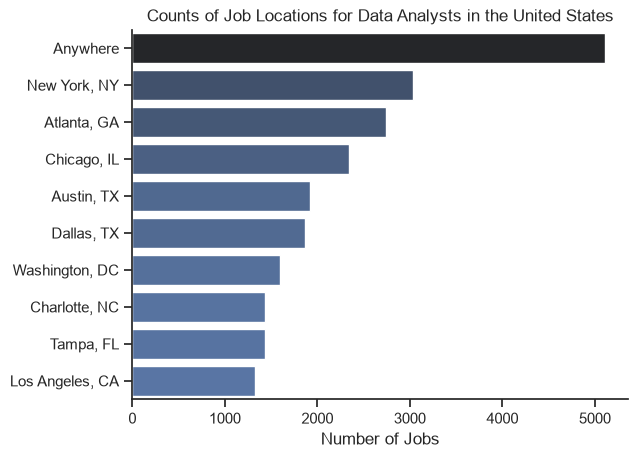

In [5]:
sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='job_location',hue='count',palette='dark:b_r',legend=False) 
sns.despine() 
plt.title('Counts of Job Locations for Data Analysts in the United States') 
plt.xlabel('Number of Jobs') 
plt.ylabel('') 
plt.show()

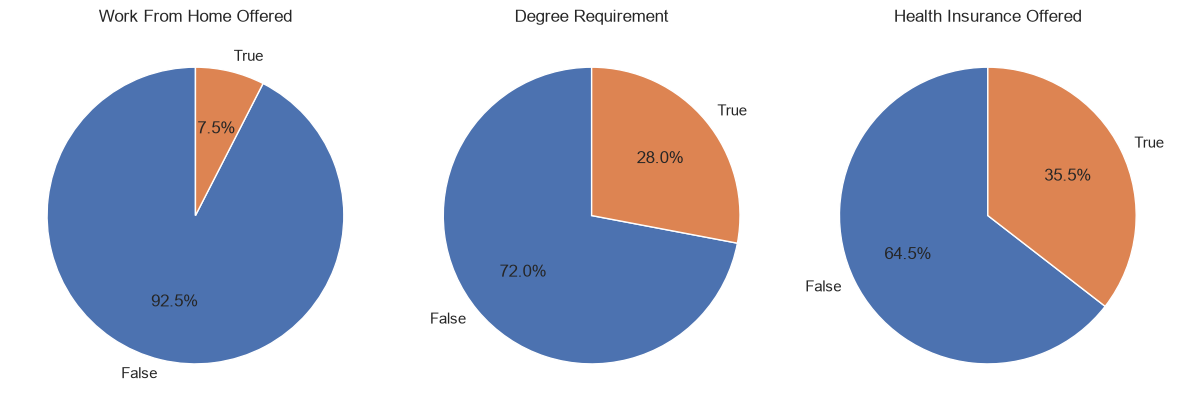

In [6]:
dict_column = {
    'job_work_from_home': 'Work From Home Offered', 
    'job_no_degree_mention' : 'Degree Requirement', 
    'job_health_insurance' : 'Health Insurance Offered'
} 

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

for i, (column, title) in enumerate(dict_column.items()):

    counts = df_DA_US[column].value_counts().reindex([False, True], fill_value=0)

    ax[i].pie(
        counts,
        labels=['False', 'True'],
        autopct='%1.1f%%',
        startangle=90
    )

    ax[i].set_title(title)

plt.tight_layout()
plt.show()

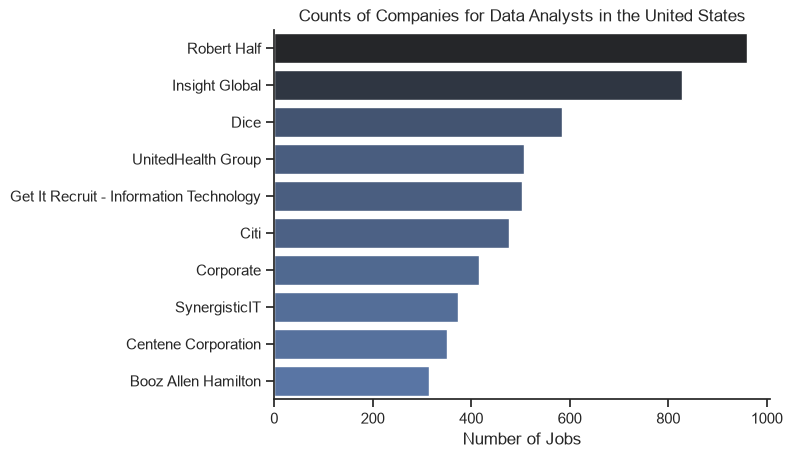

In [7]:
df_plot_company = df_DA_US['company_name'].value_counts().head(10).to_frame() 
sns.set_theme(style='ticks')
sns.barplot(data=df_plot_company,x='count',y='company_name',hue='count',palette='dark:b_r',legend=False) 
sns.despine() 
plt.title('Counts of Companies for Data Analysts in the United States') 
plt.xlabel('Number of Jobs') 
plt.ylabel('') 
plt.show()